In [1]:
import collections

city_map = {
    'A': ['B','C'],
    'B': ['A','D','E'],
    'C': ['A','F'],
    'D': ['B'],
    'E': ['B','F'],
    'F': ['C','E','G'],
    'G': ['F']
}

In [2]:
def bfs(graph, start, goal):
    queue = collections.deque([[start]])
    visited = set([start])
    explored = 0

    while queue:
        path = queue.popleft()
        node = path[-1]
        explored += 1

        if node == goal:
            return path, explored

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

    return None, explored

In [3]:
def dfs(graph, start, goal):
    stack = [(start, [start])]
    visited = set()
    explored = 0

    while stack:
        node, path = stack.pop()
        explored += 1

        if node == goal:
            return path, explored

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                stack.append((neighbor, path + [neighbor]))

    return None, explored

In [4]:
def bidirectional_bfs(graph, start, goal):
    if start == goal:
        return [start], 1

    front_queue = collections.deque([start])
    back_queue = collections.deque([goal])

    front_visited = {start: [start]}
    back_visited = {goal: [goal]}

    explored = 0

    while front_queue and back_queue:
        explored += 1

        # Expand from start side
        current = front_queue.popleft()
        for neighbor in graph[current]:
            if neighbor not in front_visited:
                front_visited[neighbor] = front_visited[current] + [neighbor]
                front_queue.append(neighbor)

                if neighbor in back_visited:
                    return front_visited[neighbor] + back_visited[neighbor][::-1][1:], explored

        # Expand from goal side
        current = back_queue.popleft()
        for neighbor in graph[current]:
            if neighbor not in back_visited:
                back_visited[neighbor] = back_visited[current] + [neighbor]
                back_queue.append(neighbor)

                if neighbor in front_visited:
                    return front_visited[neighbor] + back_visited[neighbor][::-1][1:], explored

    return None, explored

In [5]:
start, goal = 'A', 'G'

bfs_path, bfs_nodes = bfs(city_map, start, goal)
dfs_path, dfs_nodes = dfs(city_map, start, goal)
bi_path, bi_nodes = bidirectional_bfs(city_map, start, goal)

print("BFS Path:", bfs_path, "Nodes Explored:", bfs_nodes)
print("DFS Path:", dfs_path, "Nodes Explored:", dfs_nodes)
print("Bi-BFS Path:", bi_path, "Nodes Explored:", bi_nodes)

BFS Path: ['A', 'C', 'F', 'G'] Nodes Explored: 7
DFS Path: ['A', 'C', 'F', 'G'] Nodes Explored: 4
Bi-BFS Path: ['A', 'C', 'F', 'G'] Nodes Explored: 2


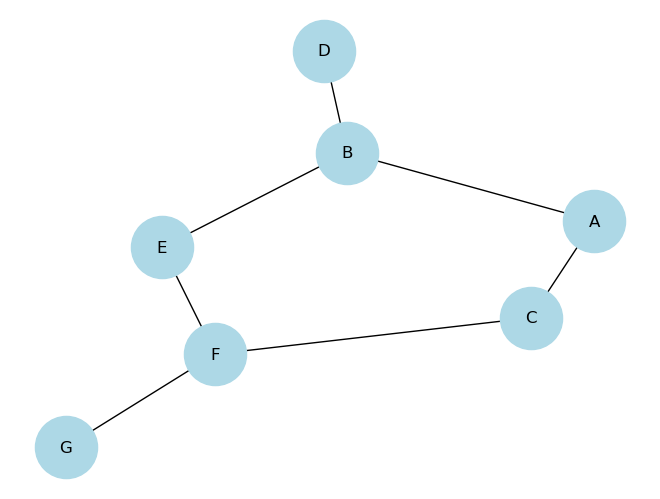

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph(city_map)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)
plt.show()

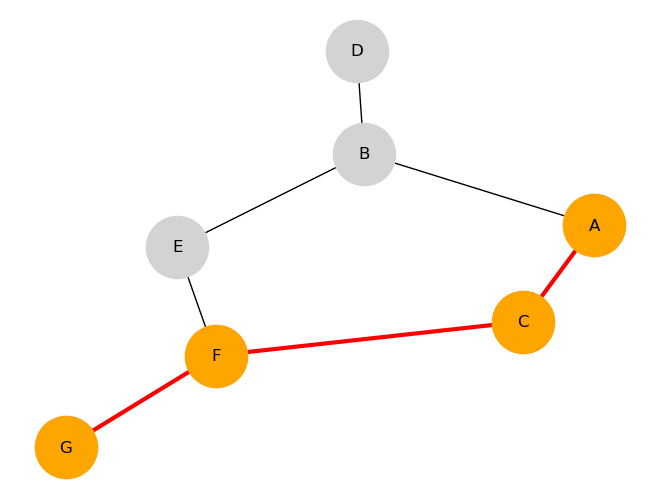

In [7]:
def draw_path(graph, path):
    G = nx.Graph(graph)
    pos = nx.spring_layout(G)

    edges = list(zip(path, path[1:]))

    nx.draw(G, pos, with_labels=True, node_color='lightgray', node_size=2000)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=3, edge_color='red')
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange', node_size=2000)
    plt.show()

draw_path(city_map, bi_path)